## 05．モデル訓練
Optunaが見つけたパラメータで最終モデルを訓練

予測結果は np.expm1 で元のWVPの単位に逆変換し、決定係数 R^2 や平均絶対誤差 MAE、誤差率 MAPE を算出

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import ast

def train_and_evaluate(X_train, X_test, y_train, y_test, best_params):
    print("--- Step 5: 最終モデル訓練 & 逆変換精度評価 ---")

    # 最適なパラメータでモデルを構築・訓練
    best_model = xgb.XGBRegressor(**best_params, random_state=42, n_jobs=-1)
    best_model.fit(X_train, y_train)

    # 予測を出力（対数スケール）
    train_preds_log = best_model.predict(X_train)
    test_preds_log = best_model.predict(X_test)

    # 逆変換：np.expm1 を使って元のWVP単位に戻す
    y_train_orig = np.expm1(y_train)
    y_test_orig = np.expm1(y_test)
    train_preds_orig = np.expm1(train_preds_log)
    test_preds_orig = np.expm1(test_preds_log)

    # MAPE（平均絶対誤差率）計算
    mask = y_test_orig != 0
    test_mape = np.mean(np.abs((y_test_orig[mask] - test_preds_orig[mask]) / y_test_orig[mask])) * 100

    # ─── 最終精度レポートの出力 ───
    print("\n" + "="*40)
    print("    📊 モデル精度評価レポート (最終結果)    ")
    print("="*40)
    print(f"【決定係数: R²】 (1.0に近いほど高性能)")
    print(f"  - 訓練データ (Train R²): {r2_score(y_train_orig, train_preds_orig):.4f}")
    print(f"  - テストデータ (Test R² ): {r2_score(y_test_orig, test_preds_orig):.4f}")
    print("-" * 40)
    print(f"【予測エラー指標】 (元のWVP単位での評価)")
    print(f"  - 二乗平均平方根誤差 (RMSE): {np.sqrt(mean_squared_error(y_test_orig, test_preds_orig)):.4f}")
    print(f"  - 平均絶対誤差       (MAE) : {mean_absolute_error(y_test_orig, test_preds_orig):.4f}")
    print(f"  - 平均絶対誤差率     (MAPE): {test_mape:.2f} %")
    print("-" * 40)

    # 誤差の分布統計
    errors = test_preds_orig - y_test_orig
    abs_errors = np.abs(errors)
    print("【テストデータの誤差分布統計】")
    print(f"  - 平均してズレている絶対量: {np.mean(abs_errors):.4f}")
    print(f"  - 最大の予測ハズレ（最大誤差）: {np.max(abs_errors):.4f}")
    print(f"  - 予測の標準偏差（ばらつき）  : {np.std(errors):.4f}")
    print("="*40)

    return best_model

#実行用
if __name__ == "__main__":
    # 1. Step 3 で保存したデータファイルを絶対パスで読み込む
    import_path = r"C:\Users\scarl\Downloads\大学関連\25講義関連\b3後期\b4\coating_ML2\coating_ML_260618\data\interim\03_split_dataset.npz"
    data = np.load(import_path, allow_pickle=True)

    cols = data['columns'].tolist()
    X_train = pd.DataFrame(data['X_train'], columns=cols)
    X_test = pd.DataFrame(data['X_test'], columns=cols)
    y_train = data['y_train']
    y_test = data['y_test']

    # 2. Step 4 でテキスト保存したベストパラメータを自動で読み込む
    param_path = r"C:\Users\scarl\Downloads\大学関連\25講義関連\b3後期\b4\coating_ML2\coating_ML_260618\data\interim\04_best_params.txt"
    try:
        with open(param_path, "r") as f:
            best_params = ast.literal_eval(f.read())
        print("Step 4 の最適パラメータを自動ロードしました。")
    except FileNotFoundError:
        # 万が一テキストファイルがない場合は、ここに手動で 04 の結果の辞書をコピペしてください
        print("⚠️ パラメータファイルが見つからないため、デフォルト値を使用します。")
        best_params = {'n_estimators': 331, 'max_depth': 9, 'learning_rate': 0.169}

    # 3. モデルの訓練と精度評価を実行
    final_model = train_and_evaluate(X_train, X_test, y_train, y_test, best_params)

Step 4 の最適パラメータを自動ロードしました。
--- Step 5: 最終モデル訓練 & 逆変換精度評価 ---

    📊 モデル精度評価レポート (最終結果)    
【決定係数: R²】 (1.0に近いほど高性能)
  - 訓練データ (Train R²): 0.8689
  - テストデータ (Test R² ): 0.7382
----------------------------------------
【予測エラー指標】 (元のWVP単位での評価)
  - 二乗平均平方根誤差 (RMSE): 1.0652
  - 平均絶対誤差       (MAE) : 0.5641
  - 平均絶対誤差率     (MAPE): 117.11 %
----------------------------------------
【テストデータの誤差分布統計】
  - 平均してズレている絶対量: 0.5641
  - 最大の予測ハズレ（最大誤差）: 8.2301
  - 予測の標準偏差（ばらつき）  : 1.0576


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(model, feature_names):
    # 1. モデルから重要度を取得
    importances = model.feature_importances_

    # 2. データフレームにまとめる
    df_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)

    # 3. テキストでランキングを出力
    print("\n" + "="*40)
    print("      🏆 特徴量重要度ランキング      ")
    print("="*40)
    for idx, row in df_importance.iterrows():
        # 【修正】 :02d のあとの「位」を波括弧の外に出しました
        print(f" {idx+1:02d}位: {row['Feature']:<25} ({row['Importance']*100:.2f} %)")
    print("="*40)


# 実行用
if __name__ == "__main__":
    try:
        feature_names = X_train.columns.tolist()
        df_imp = plot_feature_importance(final_model, feature_names)
    except NameError:
        print("⚠️ final_model または X_train が見つかりません。")
        print("05_final_training.ipynb の最終行にこのコードを貼り付けて実行してください。")


      🏆 特徴量重要度ランキング      
 01位: NumAromaticRings          (10.30 %)
 02位: NumHeteroatoms            (8.51 %)
 03位: NumHAcceptors             (8.43 %)
 04位: temperature               (7.12 %)
 05位: humidity                  (5.78 %)
 06位: NumHDonors                (4.64 %)
 07位: material_concentration    (4.62 %)
 08位: MaxAbsPartialCharge       (4.19 %)
 09位: RingCount                 (3.64 %)
 10位: FractionCSP3              (3.58 %)
 11位: NHOHCount                 (3.45 %)
 12位: TPSA                      (3.40 %)
 13位: MolMR                     (3.36 %)
 14位: MolLogP                   (3.32 %)
 15位: HallKierAlpha             (3.03 %)
 16位: proportion                (2.87 %)
 17位: Kappa2                    (2.72 %)
 18位: NOCount                   (2.56 %)
 19位: HeavyAtomMolWt            (2.41 %)
 20位: BalabanJ                  (2.39 %)
 21位: Kappa1                    (2.33 %)
 22位: NumRotatableBonds         (2.19 %)
 23位: LabuteASA                 (2.16 %)
 24位: ExactMolWt             

--- Step 6: 重要トップ2特徴量の相互作用の可視化 ---
検出されたトップ2特徴量:
  - 横軸 (X): NumHeteroatoms
  - 縦軸 (Y): NumAromaticRings


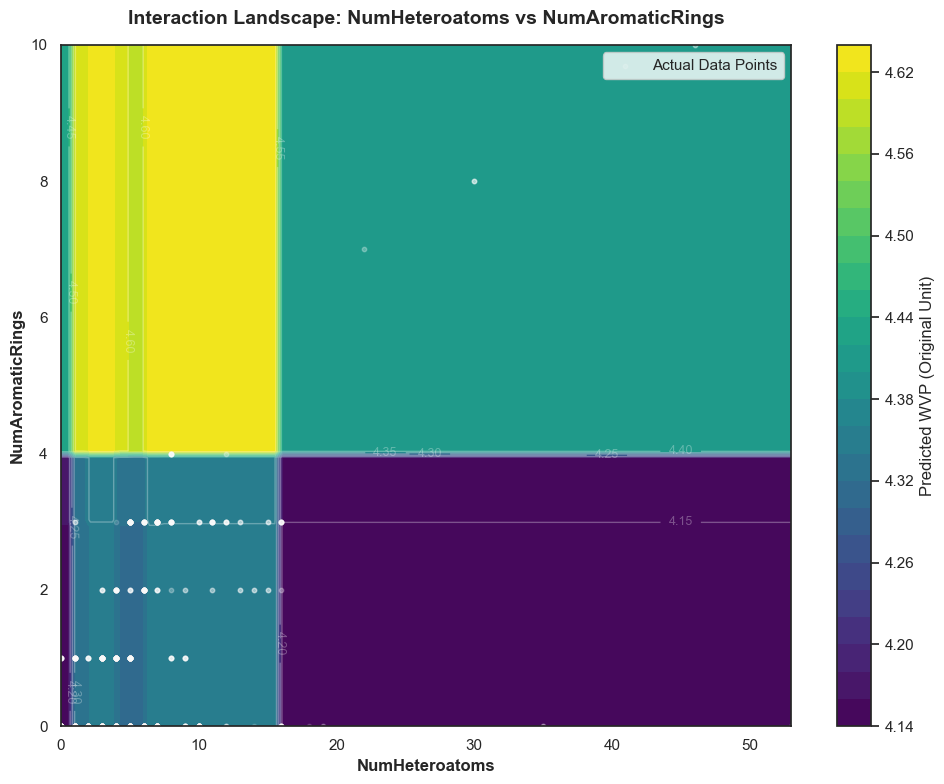

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_interaction_contour(model, X_train, feature_importance_df=None):
    print("--- Step 6: 重要トップ2特徴量の相互作用の可視化 ---")
    
    # 1. 重要トップ2の特徴量を自動特定（前回の df_imp があれば使用、なければモデルから計算）
    if feature_importance_df is not None:
        top_2_features = feature_importance_df['Feature'].head(2).tolist()
    else:
        importances = model.feature_importances_
        feat_df = pd.DataFrame({'F': X_train.columns, 'I': importances}).sort_values(by='I', ascending=False)
        top_2_features = feat_df['F'].head(2).tolist()
    
    feat_x, feat_y = top_2_features[0], top_2_features[1]
    print(f"検出されたトップ2特徴量:\n  - 横軸 (X): {feat_x}\n  - 縦軸 (Y): {feat_y}")
    
    # 2. グラフ用の格子状データ（グリッド）を作成
    x_range = np.linspace(X_train[feat_x].min(), X_train[feat_x].max(), 100)
    y_range = np.linspace(X_train[feat_y].min(), X_train[feat_y].max(), 100)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)
    
    # 3. 他の特徴量を「平均値」で固定したダミーデータを作成
    base_sample = X_train.mean().to_dict()
    
    # グリッド上の全ポイント（100x100 = 10,000点）の予測用データを作成
    plot_data = pd.DataFrame([base_sample] * (100 * 100))
    plot_data[feat_x] = X_grid.ravel()
    plot_data[feat_y] = Y_grid.ravel()
    
    # 順番を元のX_trainと完全に一致させる
    plot_data = plot_data[X_train.columns]
    
    # 4. モデルで予測して、元のWVP単位に逆変換 (np.expm1)
    preds_log = model.predict(plot_data)
    Z_grid = np.expm1(preds_log).reshape(X_grid.shape)
    
    # 5. 描画
    plt.figure(figsize=(10, 8), dpi=100)
    sns.set_theme(style="white")
    
    # 背景のカラーマップ（塗りつぶし等高線）
    contour_f = plt.contourf(X_grid, Y_grid, Z_grid, levels=30, cmap="viridis")
    cbar = plt.colorbar(contour_f)
    cbar.set_label('Predicted WVP (Original Unit)', fontsize=12)
    
    # 境界線（線としての等高線）
    contour = plt.contour(X_grid, Y_grid, Z_grid, levels=10, colors="white", alpha=0.3, linewidths=1)
    plt.clabel(contour, inline=True, fmt='%.2f', fontsize=9)
    
    # 実際のデータポイントをうっすら重ねる（モデルがどこを学んだか把握するため）
    plt.scatter(X_train[feat_x], X_train[feat_y], color='white', alpha=0.15, s=10, label='Actual Data Points')
    
    # グラフの装飾
    plt.title(f'Interaction Landscape: {feat_x} vs {feat_y}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(feat_x, fontsize=12, fontweight='bold')
    plt.ylabel(feat_y, fontsize=12, fontweight='bold')
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    plt.show()

# ─── 実行部分 ───
if __name__ == "__main__":
    try:
        # 前回のコードで作成した final_model と X_train をそのまま使います
        # もし前回の df_imp がメモリにあれば第二引数に渡すと、より確実にトップ2を捉えます
        plot_interaction_contour(final_model, X_train, df_imp if 'df_imp' in locals() else None)
    except NameError:
        print("⚠️ final_model または X_train が見て取れません。05のノートブックの最下部で実行してください。")